**SupCons**

In [13]:
import pandas as pd 
import numpy as np 
import torch
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch import nn
from timeit import default_timer as timer
from scipy import sparse
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import re
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

**Data Loading**

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'



df = pd.read_csv("F:\\university\\projects\\malware api call\\Malware Analysis Datasets API Call Sequences\\archive\dynamic_api_call_sequence_per_malware_100_0_306.csv")



<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shahin\AppData\Local\Temp\ipykernel_17884\1378521723.py:5: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("F:\\university\\projects\\malware api call\\Malware Analysis Datasets API Call Sequences\\archive\dynamic_api_call_sequence_per_malware_100_0_306.csv")


**Extract Data and Lables**

In [15]:
print(df.head())

# print(df[0])

# docs = df[0].str.lower().tolist()

# for i in range(len(docs)):
#     docs[i] = [x for x in docs[i].split(',') if x != '']



                               hash  t_0  t_1  t_2  t_3  t_4  t_5  t_6  t_7  \
0  071e8c3f8922e186e57548cd4c703a5d  112  274  158  215  274  158  215  298   
1  33f8e6d08a6aae939f25a8e0d63dd523   82  208  187  208  172  117  172  117   
2  b68abd064e975e1c6d5f25e748663076   16  110  240  117  240  117  240  117   
3  72049be7bd30ea61297ea624ae198067   82  208  187  208  172  117  172  117   
4  c9b3700a77facf29172f32df6bc77f48   82  240  117  240  117  240  117  240   

   t_8  ...  t_91  t_92  t_93  t_94  t_95  t_96  t_97  t_98  t_99  malware  
0   76  ...    71   297   135   171   215    35   208    56    71        1  
1  172  ...    81   240   117    71   297   135   171   215    35        1  
2  240  ...    65   112   123    65   112   123    65   113   112        1  
3  172  ...   208   302   208   302   187   208   302   228   302        1  
4  117  ...   209   260    40   209   260   141   260   141   260        1  

[5 rows x 102 columns]


In [16]:
lables = df['malware']
lables = torch.tensor(lables)

In [17]:


df = df.drop(columns=['hash', 'malware'])

api_seqs = df.values.tolist()
print(api_seqs[0])
print(type(api_seqs))


[112, 274, 158, 215, 274, 158, 215, 298, 76, 208, 76, 172, 117, 172, 117, 172, 76, 117, 35, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 60, 81, 117, 60, 81, 60, 81, 208, 35, 215, 35, 208, 240, 117, 172, 60, 81, 60, 81, 225, 35, 60, 81, 35, 225, 172, 60, 81, 60, 81, 60, 81, 172, 117, 76, 172, 117, 172, 117, 35, 111, 81, 140, 208, 240, 117, 71, 297, 135, 171, 215, 35, 208, 56, 71]
<class 'list'>


**Visualize Embedding**

In [18]:
def visualize_embed(X, labels, title):
    tsne = TSNE(n_components=3, init="random")
    X = tsne.fit_transform(X)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection = "3d")
    scatter = ax.scatter(X[:,0], X[:, 1], X[:,2], c= labels, cmap="viridis")

    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Class ID')

    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_zlabel('Dim 3')
    ax.set_title(title)
    plt.show()

#vectorizer1 = transformed.toarray()
#visualize_embed(transformed, labels, "hi")

**DataSet and Loader**

In [19]:

class ApiDataSet(Dataset):
    def __init__(self, data, labels):
        super().__init__()
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]  # shape [input_size=278]
        y = self.labels[idx]
        x = torch.tensor(x, dtype= torch.float32)

        # Gaussian noise
        x_noisy = x + torch.normal(0.0, 0.05, size=x.shape)

        # Add seq_len=1 dimension
        x = x.unsqueeze(0)         # [1, 278]
        x_noisy = x_noisy.unsqueeze(0)  # [1, 278]

        views = torch.stack([x, x_noisy], dim=0).squeeze(2)  # [2, 1, 278]
        return views, y





# transformed = transformed.tocoo()  
# indices = torch.tensor([transformed.row, transformed.col], dtype=torch.long)
# values = torch.tensor(transformed.data, dtype=torch.float32)

# transformed = torch.sparse_coo_tensor(indices, values, transformed.shape)


# api_data_tensor = torch.tensor(transformed, dtype = torch.float32)
# ros = RandomOverSampler(random_state=42, sampling_strategy=30000/42797)

# api_seqs ,lables = ros.fit_resample(api_seqs, lables)
lables = torch.tensor(lables, dtype = torch.long)
# 4. Create DataSet and DataLoader
dataset = ApiDataSet(api_seqs, lables)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

C:\Users\shahin\AppData\Local\Temp\ipykernel_17884\2378545643.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lables = torch.tensor(lables, dtype = torch.long)


**Model**

In [20]:
class MalDectModel(nn.Module):

    def __init__(self, input_size, hidden_dim, projection_dim):
        super(MalDectModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, batch_first=True)

        self.projection = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=projection_dim),
            nn.ReLU(),
            nn.Linear(in_features=projection_dim, out_features=projection_dim)
        )

    def forward(self,x):

        out, [hidden, cell]  = self.lstm(x)
        projection_input = hidden[-1]
        return nn.functional.normalize(self.projection(projection_input))

**Train**

In [21]:
def train_step(model, loss_fn, dataloader, optimizer):
    model.train()
    train_loss = 0
    all_emebeds , all_labels = [], []
    for seq, label in dataloader:
        seq, label = seq.to(device), label.to(device)  # [batch, 2, 1, 278]

        view1 = seq[:, 0, :, :]  # [batch, 1, 278]
        view2 = seq[:, 1, :, :]  # [batch, 1, 278]

        out1 = model(view1)      # [batch, projection_dim]
        out2 = model(view2)      # [batch, projection_dim]

        features = torch.stack([out1, out2], dim=1)  # [batch, 2, projection_dim]

        loss = loss_fn(features, label)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        all_emebeds.append(out1)
        all_emebeds.append(out2)
        all_labels.append(label)
        all_labels.append(label)
        
    all_emebeds = torch.cat(all_emebeds)
    all_labels = torch.cat(all_labels)

    all_emebeds = all_emebeds.detach().cpu().numpy()
    all_labels = all_labels.detach().cpu().numpy()
    train_loss /= len(dataloader)
    return train_loss, all_emebeds, all_labels


**Loss**

In [22]:
"""
Author: Yonglong Tian (yonglong@mit.edu)
Date: May 07, 2020
"""
from __future__ import print_function



class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07, contrast_mode='all',
                 base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature

    def forward(self, features, labels=None, mask=None):
    
        device = (torch.device('cuda')
                  if features.is_cuda
                  else torch.device('cpu'))

        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...],'
                             'at least 3 dimensions are required')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError('Num of labels does not match num of features')
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError('Unknown mode: {}'.format(self.contrast_mode))

        # compute logits
        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature)
        # for numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # tile mask
        mask = mask.repeat(anchor_count, contrast_count)
        # mask-out self-contrast cases
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # compute log_prob
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        mask_pos_pairs = mask.sum(1)
        mask_pos_pairs = torch.where(mask_pos_pairs < 1e-6, 1, mask_pos_pairs)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        # loss
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss

**Train Loop**

In [23]:
def train(model, loss_fn, optimizer, dataLoader, epochs):
    embeds, labels = None, None
    losses = []
    for epoch  in tqdm(range(epochs)):
        train_loss, embeds, labels = train_step(model, loss_fn, dataLoader, optimizer)
        losses.append(train_loss)
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f}"
            )

        
        
    visualize_embed(embeds, labels, "after using contrastive")

    return losses


**Main function**

In [24]:
from tqdm.auto import tqdm

if __name__ == "__main__":
    
    torch.manual_seed(42)
    

    model  = MalDectModel(input_size=len(api_seqs[0]), 
                          hidden_dim=128, projection_dim=128)
    model = model.to(device)
    
    loss_fn = SupConLoss(
    temperature=.07,           # Uses 0.02 from your constants
)
    optimizer = torch.optim.Adam(params=model.parameters())

    

    epochs = 100
    
    start_train = timer()
    losses = train(model=model, loss_fn=loss_fn, optimizer=optimizer,
          dataLoader=data_loader, epochs=epochs)
    model_save_path = "F:\\university\\projects\\malware_api_detection_using_supcons\\malware analyse dataset\\supconModel_v2_imbalance"
    torch.save(obj=model.state_dict(), f=model_save_path)
    print('saved')
    end_train = timer()

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 4.1424


KeyboardInterrupt: 

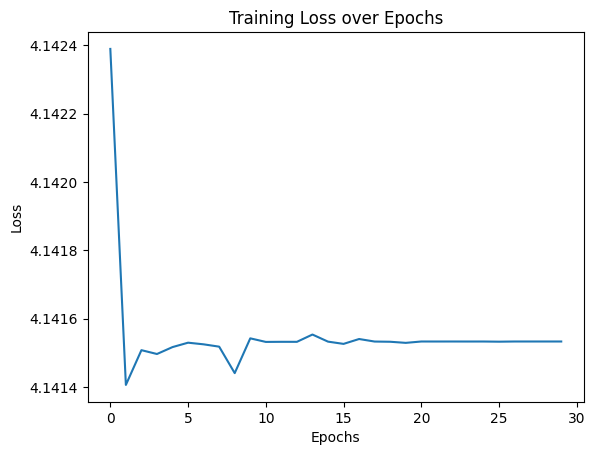

In [ ]:

plt.plot(range(epochs), losses)
plt.title("Training Loss over Epochs") 
plt.xlabel("Epochs")                   
plt.ylabel("Loss")                    
plt.show()